NAIVE BAYES CLASSIFIER EXAMPLE

Dataset Information:
  - Total samples: 150
  - Number of features: 4
  - Number of classes: 3
  - Classes: ['setosa' 'versicolor' 'virginica']

Data Split:
  - Training samples: 105
  - Testing samples: 45

Model trained successfully!

MODEL EVALUATION METRICS

Accuracy:
  - Training Accuracy: 0.9810 (98.10%)
  - Testing Accuracy: 0.9111 (91.11%)

Precision (weighted): 0.9155
Recall (weighted): 0.9111
F1 Score (weighted): 0.9107

------------------------------------------------------------
CLASSIFICATION REPORT (Per Class):
------------------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91       

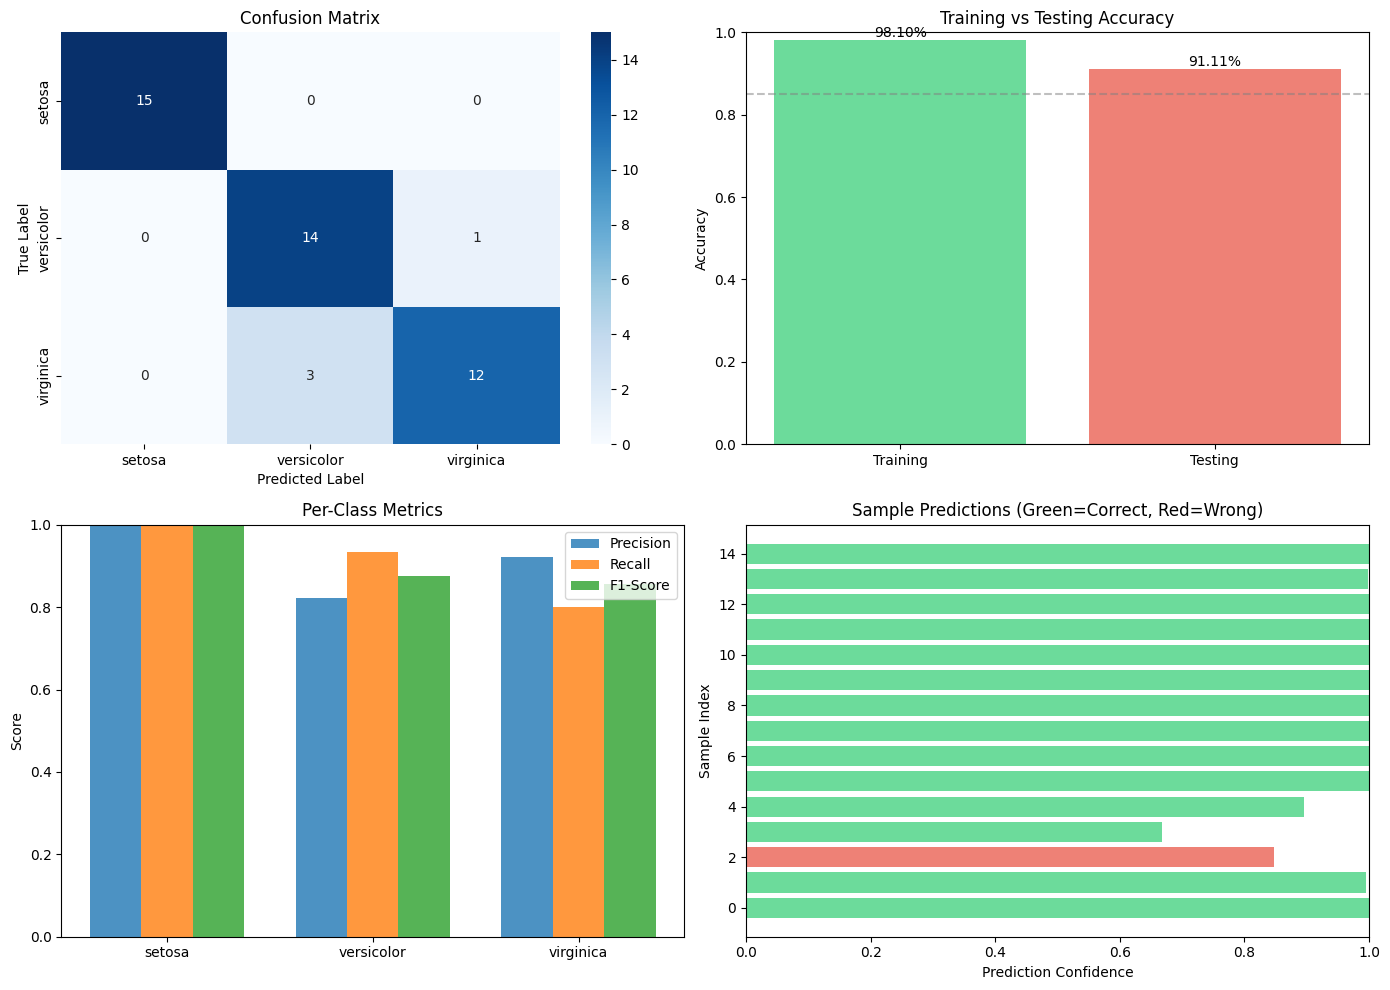


PREDICTIONS ON SAMPLE DATA

First 10 Test Samples:
Sample   Actual       Predicted    Confidence   Match   
----------------------------------------------------
1        virginica    virginica    1.0000       ✓       
2        versicolor   versicolor   0.9955       ✓       
3        virginica    versicolor   0.8472       ✗       
4        versicolor   versicolor   0.6680       ✓       
5        virginica    virginica    0.8964       ✓       
6        virginica    virginica    1.0000       ✓       
7        versicolor   versicolor   1.0000       ✓       
8        versicolor   versicolor   1.0000       ✓       
9        setosa       setosa       1.0000       ✓       
10       virginica    virginica    1.0000       ✓       

KEY INSIGHTS ABOUT NAIVE BAYES

1. WHAT IS NAIVE BAYES?
   - Probabilistic classifier based on Bayes' theorem
   - "Naive" because it assumes feature independence
   - P(Class|Features) = P(Features|Class) * P(Class) / P(Features)

2. ADVANTAGES:
   - Fast training a

In [3]:
# ============================================
# NAIVE BAYES CLASSIFIER - COMPLETE EXAMPLE
# ============================================

# Import required libraries
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ============================================
# STEP 1: LOAD AND PREPARE DATA
# ============================================
# Using the famous Iris dataset
print("=" * 60)
print("NAIVE BAYES CLASSIFIER EXAMPLE")
print("=" * 60)

# Load the Iris dataset (150 samples, 4 features, 3 classes)
iris = load_iris()
X = iris.data  # Features (sepal length, sepal width, petal length, petal width)
y = iris.target  # Target (3 iris species: 0=setosa, 1=versicolor, 2=virginica)

print(f"\nDataset Information:")
print(f"  - Total samples: {X.shape[0]}")
print(f"  - Number of features: {X.shape[1]}")
print(f"  - Number of classes: {len(np.unique(y))}")
print(f"  - Classes: {iris.target_names}")

# ============================================
# STEP 2: SPLIT DATA INTO TRAIN AND TEST
# ============================================
# 70% training, 30% testing with random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nData Split:")
print(f"  - Training samples: {X_train.shape[0]}")
print(f"  - Testing samples: {X_test.shape[0]}")

# ============================================
# STEP 3: CREATE AND TRAIN THE MODEL
# ============================================
# GaussianNB assumes features follow a Gaussian (normal) distribution
# It's simple, fast, and works well for many classification tasks
nb_classifier = GaussianNB()

# Train the model on training data
nb_classifier.fit(X_train, y_train)
print(f"\nModel trained successfully!")

# ============================================
# STEP 4: MAKE PREDICTIONS
# ============================================
# Predict on training set
y_train_pred = nb_classifier.predict(X_train)

# Predict on test set
y_test_pred = nb_classifier.predict(X_test)

# Get prediction probabilities (confidence scores)
y_test_proba = nb_classifier.predict_proba(X_test)

# ============================================
# STEP 5: EVALUATE MODEL PERFORMANCE
# ============================================
print("\n" + "=" * 60)
print("MODEL EVALUATION METRICS")
print("=" * 60)

# Calculate accuracy (percentage of correct predictions)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nAccuracy:")
print(f"  - Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  - Testing Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Precision: Of positive predictions, how many were correct?
precision = precision_score(y_test, y_test_pred, average='weighted')
print(f"\nPrecision (weighted): {precision:.4f}")

# Recall: Of actual positives, how many were found?
recall = recall_score(y_test, y_test_pred, average='weighted')
print(f"Recall (weighted): {recall:.4f}")

# F1 Score: Harmonic mean of precision and recall
f1 = f1_score(y_test, y_test_pred, average='weighted')
print(f"F1 Score (weighted): {f1:.4f}")

# Detailed classification report for each class
print("\n" + "-" * 60)
print("CLASSIFICATION REPORT (Per Class):")
print("-" * 60)
print(classification_report(y_test, y_test_pred, target_names=iris.target_names))

# Confusion Matrix: Shows correct vs incorrect predictions
cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:")
print(cm)

# ============================================
# STEP 6: VISUALIZATIONS
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Confusion Matrix Heatmap
ax1 = axes[0, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=iris.target_names, yticklabels=iris.target_names)
ax1.set_title('Confusion Matrix')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# Plot 2: Accuracy Comparison
ax2 = axes[0, 1]
accuracies = [train_accuracy, test_accuracy]
labels = ['Training', 'Testing']
colors = ['#2ecc71', '#e74c3c']
bars = ax2.bar(labels, accuracies, color=colors, alpha=0.7)
ax2.set_ylim([0, 1])
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Testing Accuracy')
ax2.axhline(y=0.85, color='gray', linestyle='--', alpha=0.5)
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2%}', ha='center', va='bottom')

# Plot 3: Per-class metrics
ax3 = axes[1, 0]
class_metrics = {
    'Precision': precision_score(y_test, y_test_pred, average=None),
    'Recall': recall_score(y_test, y_test_pred, average=None),
    'F1-Score': f1_score(y_test, y_test_pred, average=None)
}
x = np.arange(len(iris.target_names))
width = 0.25
for i, (metric, values) in enumerate(class_metrics.items()):
    ax3.bar(x + i*width, values, width, label=metric, alpha=0.8)
ax3.set_ylabel('Score')
ax3.set_title('Per-Class Metrics')
ax3.set_xticks(x + width)
ax3.set_xticklabels(iris.target_names)
ax3.legend()
ax3.set_ylim([0, 1])

# Plot 4: Sample Predictions with Confidence
ax4 = axes[1, 1]
sample_indices = range(min(15, len(y_test)))
y_test_sample = y_test[list(sample_indices)]
y_pred_sample = y_test_pred[list(sample_indices)]
y_proba_sample = np.max(y_test_proba[list(sample_indices)], axis=1)

colors_sample = ['#2ecc71' if y_test_sample[i] == y_pred_sample[i] else '#e74c3c' 
                 for i in range(len(y_test_sample))]
bars = ax4.barh(range(len(sample_indices)), y_proba_sample, color=colors_sample, alpha=0.7)
ax4.set_ylabel('Sample Index')
ax4.set_xlabel('Prediction Confidence')
ax4.set_title('Sample Predictions (Green=Correct, Red=Wrong)')
ax4.set_xlim([0, 1])

plt.tight_layout()
plt.show()

# ============================================
# STEP 7: MAKE PREDICTIONS ON NEW DATA
# ============================================
print("\n" + "=" * 60)
print("PREDICTIONS ON SAMPLE DATA")
print("=" * 60)

# Show first 10 test samples with predictions and probabilities
print("\nFirst 10 Test Samples:")
print(f"{'Sample':<8} {'Actual':<12} {'Predicted':<12} {'Confidence':<12} {'Match':<8}")
print("-" * 52)

for i in range(min(10, len(y_test))):
    actual = iris.target_names[y_test[i]]
    predicted = iris.target_names[y_test_pred[i]]
    confidence = np.max(y_test_proba[i])
    match = "✓" if y_test[i] == y_test_pred[i] else "✗"
    print(f"{i+1:<8} {actual:<12} {predicted:<12} {confidence:<12.4f} {match:<8}")

# ============================================
# KEY INSIGHTS ABOUT NAIVE BAYES
# ============================================
print("\n" + "=" * 60)
print("KEY INSIGHTS ABOUT NAIVE BAYES")
print("=" * 60)
print("""
1. WHAT IS NAIVE BAYES?
   - Probabilistic classifier based on Bayes' theorem
   - "Naive" because it assumes feature independence
   - P(Class|Features) = P(Features|Class) * P(Class) / P(Features)

2. ADVANTAGES:
   - Fast training and prediction
   - Works well with small datasets
   - Handles high-dimensional data efficiently
   - Provides probability estimates

3. DISADVANTAGES:
   - Assumes feature independence (not always true)
   - Sensitive to feature scaling
   - May perform poorly if assumptions violated

4. WHEN TO USE:
   - Text classification (spam detection, sentiment analysis)
   - Real-time predictions needed
   - Small training datasets
   - High-dimensional data

5. VARIANTS:
   - GaussianNB: For continuous data (assumes Gaussian distribution)
   - MultinomialNB: For discrete counts (text, document classification)
   - BernoulliNB: For binary features
""")

print("=" * 60)
print("NAIVE BAYES EXAMPLE COMPLETE!")
print("=" * 60)